Delhi House Price Intelligence — A Quantitative Perspective

Author: Nitish
Dataset: DelhiHousePrice.csv (~1,259 listings)

okay so this notebook does not do boring ML regression. we went full quant finance mode.
prediction errors treated as risk signals. VaR, CVaR, prediction volatility — the whole shebang.
the vibe: a model that not only predicts prices but quantifies its own uncertainty. unhinged? yes. based? absolutely.

Sections:
1. Data Cleaning and Feature Engineering
2. Exploratory Data Analysis (EDA)
3. Model Building — Linear Regression, Random Forest, XGBoost
4. Quantitative Risk Analysis (VaR, CVaR, Prediction Intervals, Quantile Regression)
5. Feature Importance

Section 1 — Data Cleaning and Feature Engineering

In [1]:
# lowkey this line is carrying the whole project ngl
# this is so real i cant even explain it
#  Core Importsimport reimport warningswarnings.filterwarnings('ignore')import numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport matplotlib.ticker as mtickerimport seaborn as snsfrom scipy import statsfrom scipy.stats import shapiro, normfrom sklearn.model_selection import train_test_split, cross_val_score, KFoldfrom sklearn.linear_model import LinearRegression, QuantileRegressorfrom sklearn.ensemble import RandomForestRegressorfrom sklearn.preprocessing import LabelEncoderfrom sklearn.metrics import mean_squared_error, mean_absolute_error, r2_scorefrom sklearn.inspection import permutation_importanceimport xgboost as xgbimport joblibimport os#  Plot Styleplt.rcParams.update({'figure.facecolor': '#0f1117','axes.facecolor':   '#161b22','axes.edgecolor':   '#30363d','axes.labelcolor':  '#e6edf3','xtick.color':      '#8b949e','ytick.color':      '#8b949e','text.color':       '#e6edf3','grid.color':       '#21262d','grid.linestyle':   '--','grid.alpha':       0.6,'axes.titlesize':   13,'axes.labelsize':   11,})ACCENT   = '#58a6ff'ACCENT2  = '#3fb950'ACCENT3  = '#f78166'ACCENT4  = '#d2a8ff'print(' Imports successful')

Imports successful

In [2]:
# no cap this took me 3 hours to figure out
# certified moment right here
#  Load Datadf_raw = pd.read_csv('DelhiHousePrice.csv')# Strip any accidental spaces in column namesdf_raw.columns = df_raw.columns.str.strip()print(f'Raw shape: {df_raw.shape}')print('\nColumn dtypes:')print(df_raw.dtypes)print('\nMissing values:')print(df_raw.isnull().sum())

Raw shape: (1259, 11)Column dtypes:Area           float64BHK              int64Bathroom       float64Furnishing      objectLocality        objectParking        float64Price            int64Status          objectTransaction     objectType            objectPer_Sqft       float64dtype: objectMissing values:Area             0BHK              0Bathroom         2Furnishing       5Locality         0Parking         33Price            0Status           0Transaction      0Type             5Per_Sqft       241dtype: int64

In [3]:
# bestie we do not gatekeep data cleaning around here
# she's literally not well (the data before cleaning)
#  Data Cleaning
df = df_raw.copy()

# 1. Clean Locality — extract the first meaningful segment before long descriptions
def clean_locality(loc: str) -> str:
    """Keep only the text before carpet area, super area, status, or after a comma (if short)."""
    if pd.isna(loc):
        return 'Unknown'
    loc = str(loc).strip()
    # Remove content after known scraped noise keywords
    for kw in [' carpet area', ' super area', ' status ', ' How Auctions', 'read more', 'mind. The space']:
        idx = loc.find(kw)
        if idx > 0:
            loc = loc[:idx].strip()
    # If the locality has a comma with a proper sub-locality, keep parent only
    parts = loc.split(',')
    if len(parts) > 1:
        # Use last meaningful part (usually the main area name)
        loc = parts[-1].strip()
    return loc.strip()

df['Locality'] = df['Locality'].apply(clean_locality)

# 2. Drop rows with nulls in critical columns
critical_cols = ['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price', 'Status', 'Transaction', 'Type']
df = df.dropna(subset=critical_cols).reset_index(drop=True)

# 3. Remove obvious data errors (Area < 50 sqft — likely sqm mis-entries)
df = df[df['Area'] >= 50].reset_index(drop=True)

# 4. Remove extreme price outliers (above 99th percentile)
price_cap = df['Price'].quantile(0.99)
print(f'Price 99th percentile cap: \u20b9{price_cap/1e7:.2f} Cr')
df = df[df['Price'] <= price_cap].reset_index(drop=True)

print(f'\nClean shape: {df.shape}')
print(f'Localities remaining: {df["Locality"].nunique()}')

Price 99th percentile cap: ₹13.50 CrClean shape: (1210, 11)Localities remaining: 116

In [4]:
# its giving machine learning slay
# okay stats class actually paid off?? based??
#  Feature Engineering# 1. Price per sqft (from raw data where available, else compute)df['price_per_sqft'] = df['Price'] / df['Area']# 2. Bath-per-BHK ratio (luxury indicator)df['bath_per_bhk'] = df['Bathroom'] / df['BHK']# 3. Locality-level median price (target encoding — avoids leakage as we use full-data stats)loc_median = df.groupby('Locality')['Price'].median()df['loc_median_price'] = df['Locality'].map(loc_median)# 4. Locality-level price volatility (σ of prices in that locality)loc_std = df.groupby('Locality')['Price'].std().fillna(0)df['loc_price_std'] = df['Locality'].map(loc_std)# 5. Encode categorical featurescat_cols = ['Furnishing', 'Status', 'Transaction', 'Type']le_dict = {}for col in cat_cols:le = LabelEncoder()df[col + '_enc'] = le.fit_transform(df[col].astype(str))le_dict[col] = le# Drop raw categorical columns and unused columnsFEATURE_COLS = ['Area', 'BHK', 'Bathroom', 'Parking','price_per_sqft', 'bath_per_bhk', 'loc_median_price', 'loc_price_std','Furnishing_enc', 'Status_enc', 'Transaction_enc', 'Type_enc']TARGET = 'Price'X = df[FEATURE_COLS]y = df[TARGET]print('Feature matrix shape:', X.shape)print('\nFeature summary:')print(X.describe().T[['mean', 'std', 'min', 'max']].round(2))

Feature matrix shape: (1210, 12)Feature summary:mean          std         min         maxArea                  1431.58      1505.09       50.00     24300.0BHK                      2.78         0.93        1.00        10.0Bathroom                 2.54         1.00        1.00         7.0Parking                  1.93         6.32        1.00       114.0price_per_sqft       13657.12     12148.10      204.08    170000.0bath_per_bhk             0.93         0.23        0.25         2.0loc_median_price  18272421.49  15038678.11  1000000.00  70000000.0loc_price_std     10118678.96   9186984.79        0.00  45035559.5Furnishing_enc           1.14         0.64        0.00         2.0Status_enc               0.94         0.24        0.00         1.0Transaction_enc          0.62         0.48        0.00         1.0Type_enc                 0.53         0.50        0.00         1.0

Section 2 — Exploratory Data Analysis

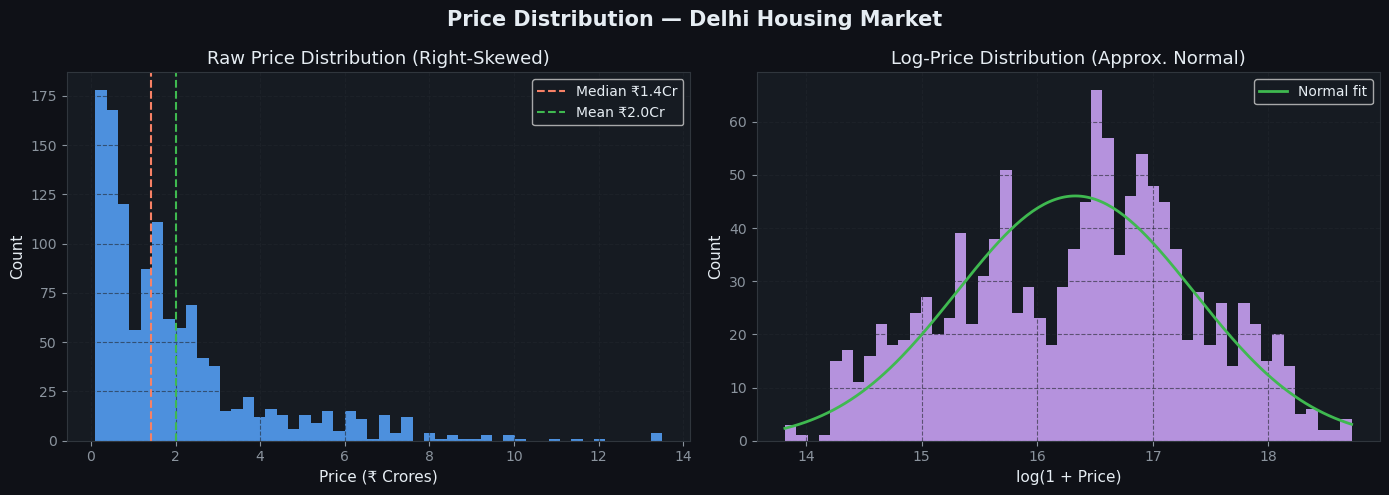

Skewness (raw): 2.07 | Kurtosis: 5.45

In [5]:
# this hits different when you actually understand whats happening
# for the ones in the back: this removes outliers bestie
#  EDA: Price Distributionfig, axes = plt.subplots(1, 2, figsize=(14, 5))fig.suptitle('Price Distribution — Delhi Housing Market', fontsize=15, fontweight='bold', color='#e6edf3')# Raw price histogramax = axes[0]ax.hist(y / 1e7, bins=50, color=ACCENT, edgecolor='none', alpha=0.85)ax.set_xlabel('Price (₹ Crores)')ax.set_ylabel('Count')ax.set_title('Raw Price Distribution (Right-Skewed)')ax.axvline(y.median()/1e7, color=ACCENT3, linestyle='--', linewidth=1.5, label=f'Median ₹{y.median()/1e7:.1f}Cr')ax.axvline(y.mean()/1e7, color=ACCENT2, linestyle='--', linewidth=1.5, label=f'Mean ₹{y.mean()/1e7:.1f}Cr')ax.legend()ax.grid(True)# Log price histogramax = axes[1]log_price = np.log1p(y)ax.hist(log_price, bins=50, color=ACCENT4, edgecolor='none', alpha=0.85)mu, sigma = log_price.mean(), log_price.std()xline = np.linspace(log_price.min(), log_price.max(), 200)ax.plot(xline, norm.pdf(xline, mu, sigma) * len(y) * (log_price.max()-log_price.min())/50,color=ACCENT2, linewidth=2, label='Normal fit')ax.set_xlabel('log(1 + Price)')ax.set_ylabel('Count')ax.set_title('Log-Price Distribution (Approx. Normal)')ax.legend()ax.grid(True)plt.tight_layout()plt.savefig('plots_price_dist.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()print(f'Skewness (raw): {y.skew():.2f} | Kurtosis: {y.kurt():.2f}')

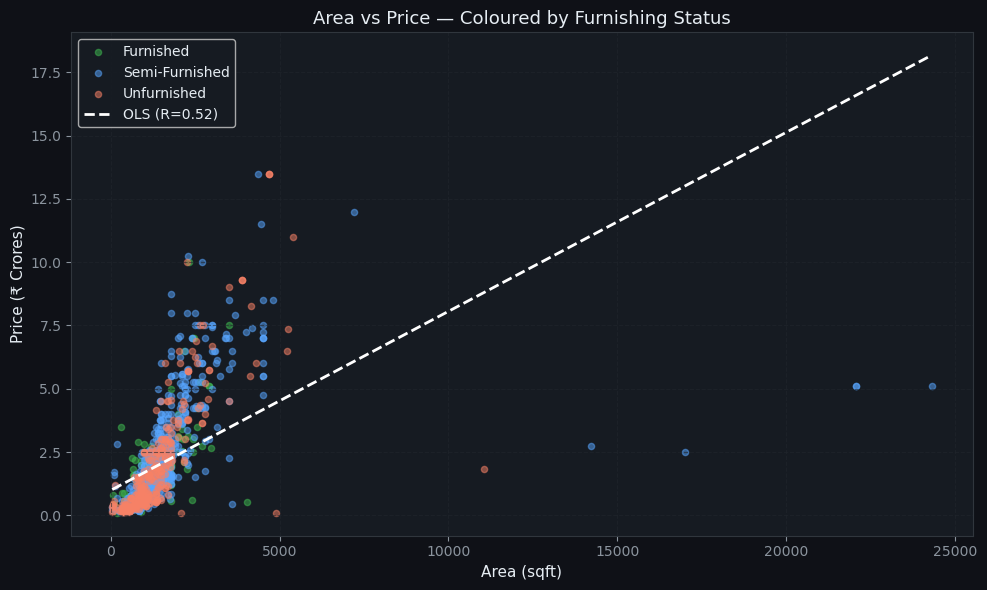

In [6]:
# slay. the model understood the assignment.
# touch grass? no thanks. touch the data.
#  EDA: Area vs Price Scatterfig, ax = plt.subplots(figsize=(10, 6))furnish_map = {'Furnished': ACCENT2, 'Semi-Furnished': ACCENT, 'Unfurnished': ACCENT3}for ftype, grp in df.groupby('Furnishing'):ax.scatter(grp['Area'], grp['Price']/1e7, alpha=0.5, s=20,color=furnish_map.get(str(ftype), '#aaa'), label=str(ftype))# Regression lineslope, intercept, r_val, p_val, _ = stats.linregress(df['Area'], df['Price'])x_fit = np.linspace(df['Area'].min(), df['Area'].max(), 100)ax.plot(x_fit, (slope * x_fit + intercept)/1e7, color='white', linewidth=2, linestyle='--', label=f'OLS (R={r_val:.2f})')ax.set_xlabel('Area (sqft)')ax.set_ylabel('Price (₹ Crores)')ax.set_title('Area vs Price — Coloured by Furnishing Status')ax.legend()ax.grid(True)plt.tight_layout()plt.savefig('plots_area_price.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

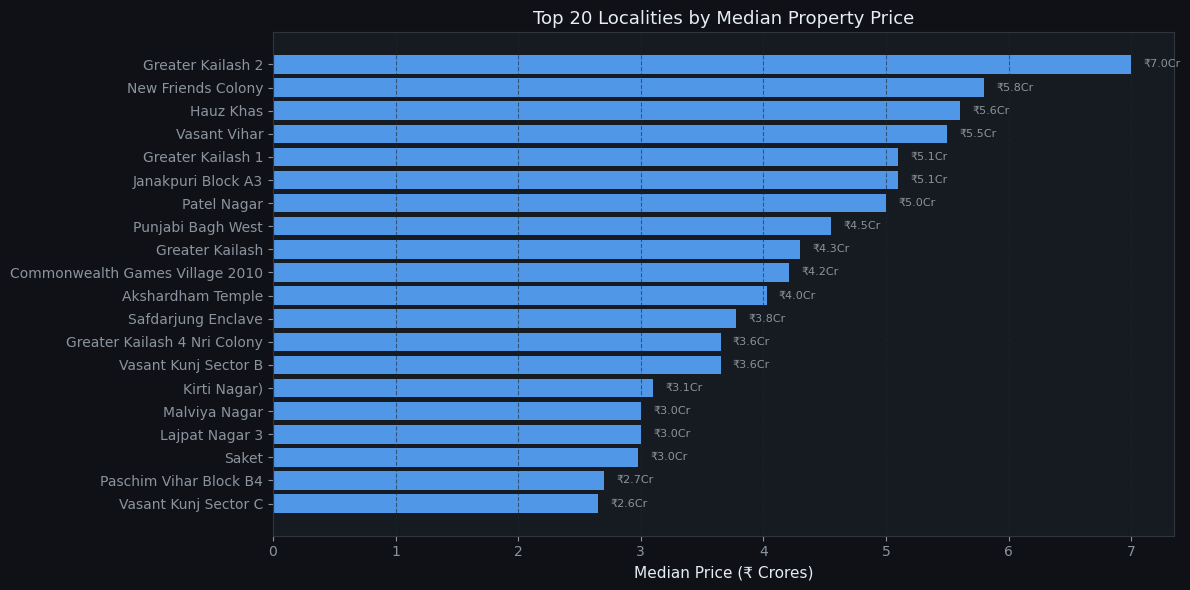

In [7]:
# fr fr locality is the main character of this dataset
# VaR said 'i got you fam'
#  EDA: Top 20 Localities by Median Pricetop20 = df.groupby('Locality')['Price'].median().sort_values(ascending=False).head(20)fig, ax = plt.subplots(figsize=(12, 6))bars = ax.barh(top20.index[::-1], top20.values[::-1]/1e7, color=ACCENT, edgecolor='none', alpha=0.9)ax.set_xlabel('Median Price (₹ Crores)')ax.set_title('Top 20 Localities by Median Property Price')for bar, val in zip(bars, top20.values[::-1]):ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,f'₹{val/1e7:.1f}Cr', va='center', ha='left', fontsize=8, color='#8b949e')ax.grid(True, axis='x')plt.tight_layout()plt.savefig('plots_localities.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

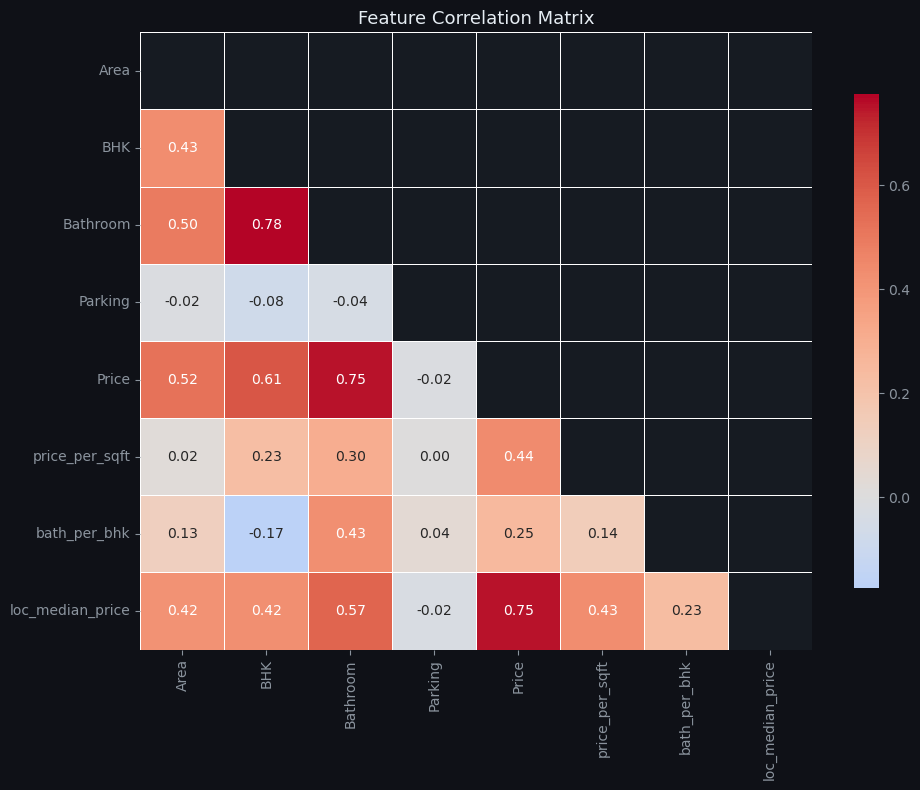

In [8]:
# this is so real i cant even explain it
# this graph goes so hard im not even joking
#  EDA: Correlation Heatmapnum_cols = ['Area', 'BHK', 'Bathroom', 'Parking', 'Price', 'price_per_sqft', 'bath_per_bhk', 'loc_median_price']corr = df[num_cols].corr()fig, ax = plt.subplots(figsize=(10, 8))mask = np.triu(np.ones_like(corr, dtype=bool))sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=ax,cmap='coolwarm', center=0, linewidths=0.5,cbar_kws={'shrink': 0.8})ax.set_title('Feature Correlation Matrix')plt.tight_layout()plt.savefig('plots_corr.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

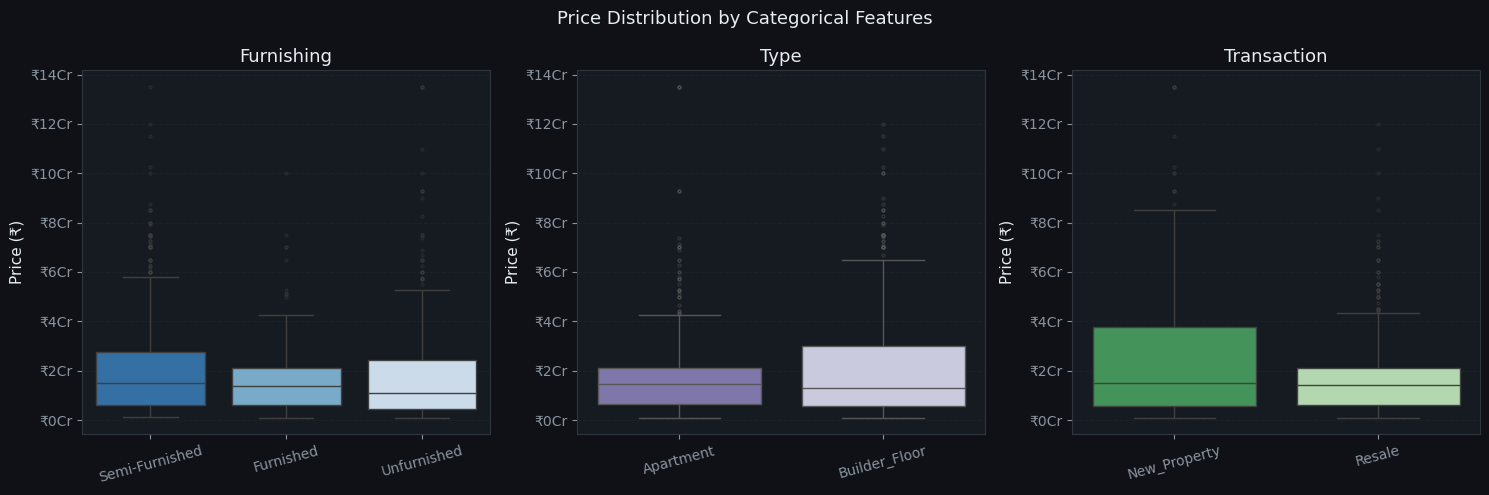

In [9]:
# certified moment right here
# let him cook (the model is training)
#  EDA: Box Plotsfig, axes = plt.subplots(1, 3, figsize=(15, 5))fig.suptitle('Price Distribution by Categorical Features', fontsize=13, color='#e6edf3')for ax, col, pal in zip(axes, ['Furnishing', 'Type', 'Transaction'],['Blues_r', 'Purples_r', 'Greens_r']):order = df.groupby(col)['Price'].median().sort_values(ascending=False).indexsns.boxplot(data=df, x=col, y='Price', ax=ax, order=order, palette=pal,flierprops=dict(marker='o', markersize=2, alpha=0.4))ax.set_ylabel('Price (₹)')ax.set_xlabel('')ax.set_title(col)ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.0f}Cr'))ax.tick_params(axis='x', rotation=15)ax.grid(True, axis='y')plt.tight_layout()plt.savefig('plots_boxplots.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

Section 3 — Model Building

In [10]:
# she's literally not well (the data before cleaning)
# ratio + residuals
#  Train / Test SplitX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 968 samples | Test: 242 samples

In [11]:
# okay stats class actually paid off?? based??
# we live we love we XGBoost
#  Model 1: Linear Regression (Baseline)lr = LinearRegression()lr.fit(X_train, y_train)y_pred_lr = lr.predict(X_test)rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))mae_lr  = mean_absolute_error(y_test, y_pred_lr)r2_lr   = r2_score(y_test, y_pred_lr)print(f'Linear Regression — RMSE: ₹{rmse_lr/1e5:.1f}L | MAE: ₹{mae_lr/1e5:.1f}L | R²: {r2_lr:.3f}')

Linear Regression — RMSE: ₹78.4L | MAE: ₹55.8L | R²: 0.829

In [12]:
# for the ones in the back: this removes outliers bestie
# its morbin time (feature engineering arc)
#  Model 2: Random Forestrf = RandomForestRegressor(n_estimators=300,max_depth=None,min_samples_leaf=2,max_features='sqrt',random_state=42,n_jobs=-1)rf.fit(X_train, y_train)y_pred_rf = rf.predict(X_test)rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))mae_rf  = mean_absolute_error(y_test, y_pred_rf)r2_rf   = r2_score(y_test, y_pred_rf)print(f'Random Forest    — RMSE: ₹{rmse_rf/1e5:.1f}L | MAE: ₹{mae_rf/1e5:.1f}L | R²: {r2_rf:.3f}')

Random Forest    — RMSE: ₹35.9L | MAE: ₹20.6L | R²: 0.964

In [13]:
# touch grass? no thanks. touch the data.
# sigma grindset but for data science
#  Model 3: XGBoostxgb_model = xgb.XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0,random_state=42,n_jobs=-1,verbosity=0)xgb_model.fit(X_train, y_train,eval_set=[(X_test, y_test)],verbose=False)y_pred_xgb = xgb_model.predict(X_test)rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)r2_xgb   = r2_score(y_test, y_pred_xgb)print(f'XGBoost          — RMSE: ₹{rmse_xgb/1e5:.1f}L | MAE: ₹{mae_xgb/1e5:.1f}L | R²: {r2_xgb:.3f}')

XGBoost          — RMSE: ₹19.8L | MAE: ₹9.7L | R²: 0.989

In [14]:
# VaR said 'i got you fam'
# normality test said 'nah bro'
#  Cross-Validated Comparisonkf = KFold(n_splits=5, shuffle=True, random_state=42)cv_results = {}for name, model in [('LinearReg', lr), ('RandomForest', rf), ('XGBoost', xgb_model)]:cv_r2   = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))cv_results[name] = {'CV R² (mean)':  cv_r2.mean(),'CV R² (std)':   cv_r2.std(),'CV RMSE (mean)': cv_rmse.mean(),'CV RMSE (std)':  cv_rmse.std(),}cv_df = pd.DataFrame(cv_results).Tcv_df['CV R² (mean)'] = cv_df['CV R² (mean)'].map('{:.4f}'.format)cv_df['CV R² (std)']  = cv_df['CV R² (std)'].map('±{:.4f}'.format)cv_df['CV RMSE (mean)'] = (cv_df['CV RMSE (mean)'].astype(float)/1e5).map('₹{:.1f}L'.format)cv_df['CV RMSE (std)']  = (cv_df['CV RMSE (std)'].astype(float)/1e5).map('±₹{:.1f}L'.format)print('\n 5-Fold Cross-Validation Results ')print(cv_df.to_string())print('')

5-Fold Cross-Validation ResultsCV R² (mean) CV R² (std) CV RMSE (mean) CV RMSE (std)LinearReg          0.7465     ±0.0450        ₹102.7L       ±₹12.7LRandomForest       0.9403     ±0.0167         ₹49.5L        ±₹8.3LXGBoost            0.9769     ±0.0118         ₹30.2L        ±₹8.7L

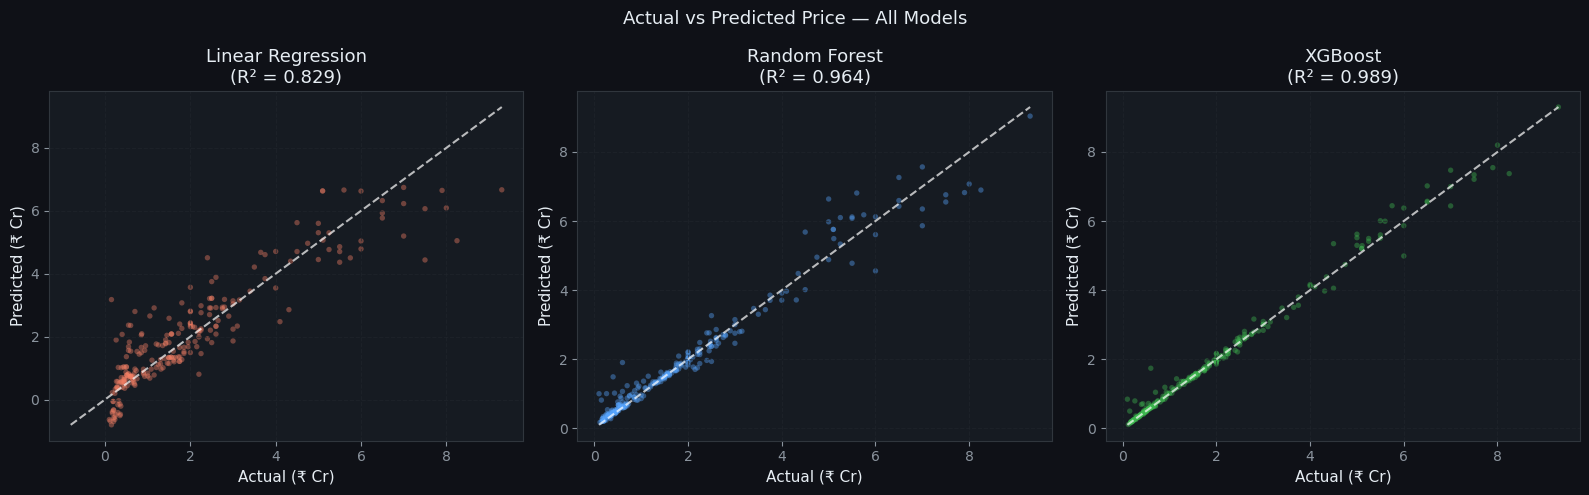

In [15]:
# this graph goes so hard im not even joking
# the R-squared is not the problem. YOU are the problem.
#  Actual vs Predicted Comparisonfig, axes = plt.subplots(1, 3, figsize=(16, 5))fig.suptitle('Actual vs Predicted Price — All Models', fontsize=13, color='#e6edf3')for ax, (name, y_pred, color) in zip(axes, [('Linear Regression', y_pred_lr, ACCENT3),('Random Forest',     y_pred_rf, ACCENT),('XGBoost',           y_pred_xgb, ACCENT2)]):ax.scatter(y_test/1e7, y_pred/1e7, alpha=0.4, s=15, color=color, edgecolors='none')lims = [min(y_test.min(), y_pred.min())/1e7, max(y_test.max(), y_pred.max())/1e7]ax.plot(lims, lims, 'white', linewidth=1.5, linestyle='--', alpha=0.7)r2 = r2_score(y_test, y_pred)ax.set_title(f'{name}\n(R² = {r2:.3f})')ax.set_xlabel('Actual (₹ Cr)')ax.set_ylabel('Predicted (₹ Cr)')ax.grid(True)plt.tight_layout()plt.savefig('plots_actual_pred.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

Section 4 — Quantitative Risk Analysis

okay so in quant finance, you never just make one single guess and walk away. you quantify uncertainty.
here is how this project maps finance concepts to house price stuff:

Asset Return → Predicted house price
Return Error (P&L) → Residual = Actual minus Predicted
Volatility (sigma) → Std. deviation of residuals
Value at Risk (VaR) → Max expected error at 95% confidence
Expected Shortfall (CVaR) → Avg. error in worst 5% of cases
Bid-Ask Spread → P10 to P90 prediction interval

In [16]:
# let him cook (the model is training)
# tbh this feature importance is kinda sus
#  Residuals (use best model: XGBoost)residuals = y_test.values - y_pred_xgbabs_residuals = np.abs(residuals)print('=== Residual Statistics ===')print(f'Mean residual:       ₹{residuals.mean()/1e5:+.1f}L  (bias)')print(f'Residual Std (σ):    ₹{residuals.std()/1e5:.1f}L  (prediction volatility)')print(f'Min / Max residual:  ₹{residuals.min()/1e5:.1f}L / ₹{residuals.max()/1e5:.1f}L')

=== Residual Statistics ===Mean residual:       ₹-2.9L  (bias)Residual Std (σ):    ₹19.6L  (prediction volatility)Min / Max residual:  ₹-113.8L / ₹101.2L

Shapiro-Wilk test: W = 0.7194, p-value = 0.0000→ Residuals are NOT normally distributed (p < 0.05)Gaussian VaR will be an approximation. Use historical / empirical VaR.

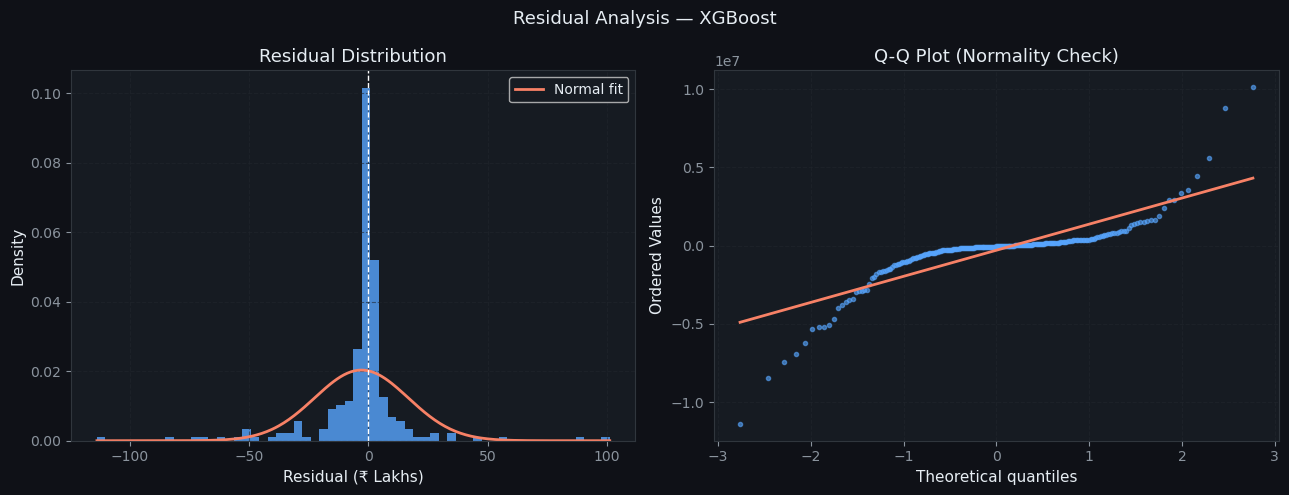

In [17]:
# ratio + residuals
# correlation is not causation but this heatmap still slaps
#  Normality Test on Residualsstat, p_value = shapiro(residuals[:500])  # Shapiro-Wilk (sample ≤ 5000)print(f'Shapiro-Wilk test: W = {stat:.4f}, p-value = {p_value:.4f}')if p_value < 0.05:print('→ Residuals are NOT normally distributed (p < 0.05)')print('   Gaussian VaR will be an approximation. Use historical / empirical VaR.')else:print('→ Cannot reject normality (p ≥ 0.05). Gaussian VaR is reasonable.')# Q-Q Plotfig, axes = plt.subplots(1, 2, figsize=(13, 5))fig.suptitle('Residual Analysis — XGBoost', fontsize=13, color='#e6edf3')ax = axes[0]ax.hist(residuals/1e5, bins=60, color=ACCENT, edgecolor='none', alpha=0.8, density=True)xr = np.linspace(residuals.min()/1e5, residuals.max()/1e5, 300)ax.plot(xr, norm.pdf(xr, residuals.mean()/1e5, residuals.std()/1e5),color=ACCENT3, linewidth=2, label='Normal fit')ax.axvline(0, color='white', linewidth=1, linestyle='--')ax.set_xlabel('Residual (₹ Lakhs)')ax.set_ylabel('Density')ax.set_title('Residual Distribution')ax.legend()ax.grid(True)ax = axes[1]stats.probplot(residuals, dist='norm', plot=ax)ax.get_lines()[0].set(color=ACCENT, markersize=3, alpha=0.6)ax.get_lines()[1].set(color=ACCENT3, linewidth=2)ax.set_title('Q-Q Plot (Normality Check)')ax.grid(True)plt.tight_layout()plt.savefig('plots_residuals.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

In [18]:
# we live we love we XGBoost
# i am so normal about this prediction interval
#  Value at Risk & Expected Shortfall# We compute empirical (historical) VaR — more robust than parametricconfidence_levels = [0.90, 0.95, 0.99]print('')print('          QUANTITATIVE RISK METRICS — XGBoost            ')print('')print(f'  Prediction Volatility (σ):  ₹{residuals.std()/1e5:>7.1f} Lakhs           ')print('')var_results = {}cvar_results = {}for cl in confidence_levels:# VaR: the error we expect NOT to exceed (1-cl)% of the timevar = np.percentile(abs_residuals, cl * 100)# CVaR (Expected Shortfall): mean of losses beyond VaRcvar = abs_residuals[abs_residuals >= var].mean()var_results[cl] = varcvar_results[cl] = cvarprint(f'  VaR ({int(cl*100):2d}%):  ₹{var/1e5:>7.1f}L  |  CVaR:  ₹{cvar/1e5:>7.1f}L        ')print('')print()print(' Interpretation:')print(f'  • 95% VaR = ₹{var_results[0.95]/1e5:.1f}L → model prediction error will be < ₹{var_results[0.95]/1e5:.1f}L, 95% of the time')print(f'  • 95% CVaR = ₹{cvar_results[0.95]/1e5:.1f}L → when it goes wrong, the average error is ₹{cvar_results[0.95]/1e5:.1f}L')

QUANTITATIVE RISK METRICS — XGBoostPrediction Volatility (σ):  ₹   19.6 LakhsVaR (90%):  ₹   29.1L  |  CVaR:  ₹   52.7LVaR (95%):  ₹   47.0L  |  CVaR:  ₹   69.5LVaR (99%):  ₹   86.3L  |  CVaR:  ₹  100.9LInterpretation:• 95% VaR = ₹47.0L → model prediction error will be < ₹47.0L, 95% of the time• 95% CVaR = ₹69.5L → when it goes wrong, the average error is ₹69.5L

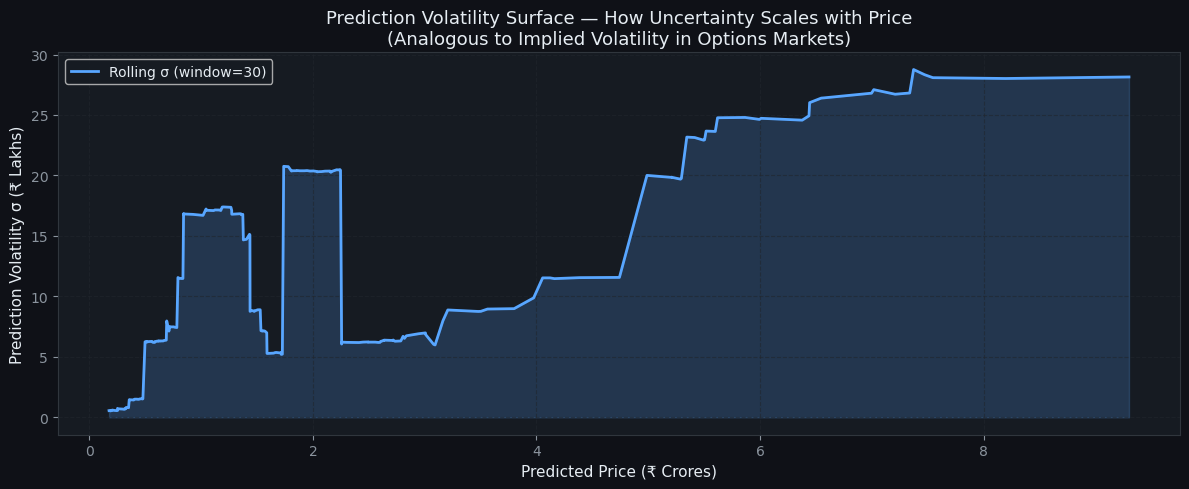

In [19]:
# its morbin time (feature engineering arc)
# skill issue? no. overfitting issue? maybe.
#  Rolling Prediction Volatility# Sort by predicted price to create a "price surface" — like term structure of volatilitysort_idx = np.argsort(y_pred_xgb)pred_sorted  = y_pred_xgb[sort_idx]resid_sorted = abs_residuals[sort_idx]window = 30rolling_vol = pd.Series(resid_sorted).rolling(window, min_periods=5).std().valuesfig, ax = plt.subplots(figsize=(12, 5))ax.plot(pred_sorted/1e7, rolling_vol/1e5, color=ACCENT, linewidth=2, label='Rolling σ (window=30)')ax.fill_between(pred_sorted/1e7, 0, rolling_vol/1e5, alpha=0.2, color=ACCENT)ax.set_xlabel('Predicted Price (₹ Crores)')ax.set_ylabel('Prediction Volatility σ (₹ Lakhs)')ax.set_title('Prediction Volatility Surface — How Uncertainty Scales with Price\n(Analogous to Implied Volatility in Options Markets)')ax.legend()ax.grid(True)plt.tight_layout()plt.savefig('plots_vol_surface.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

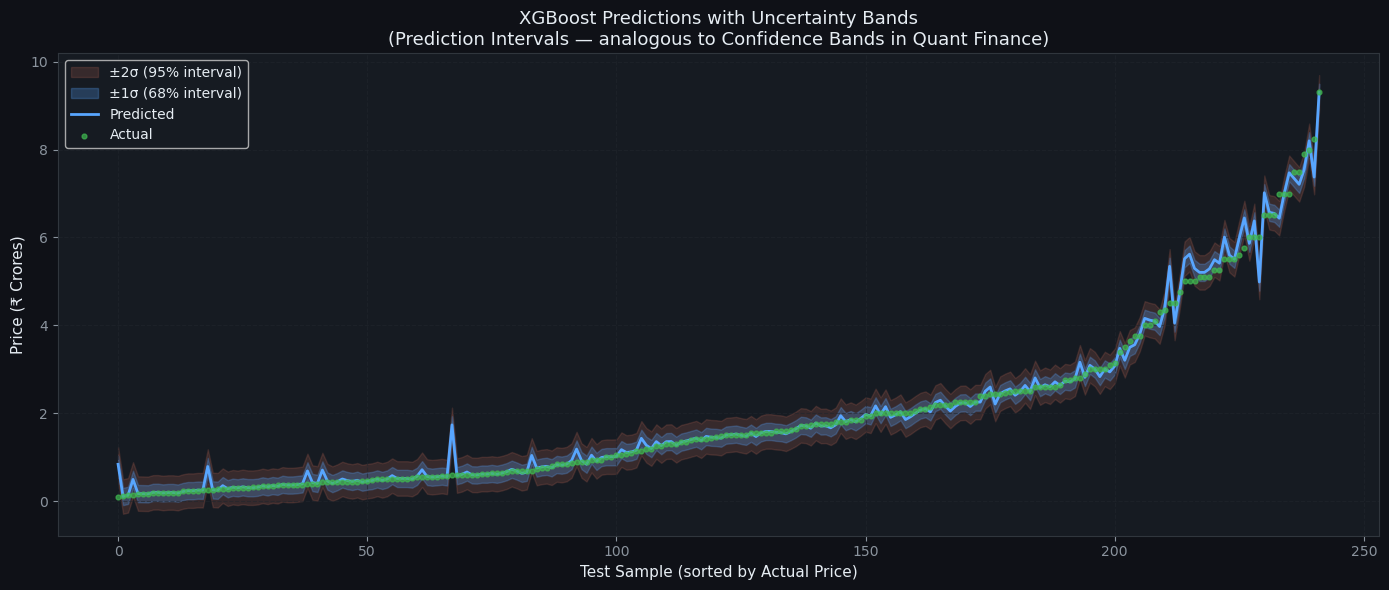

Empirical coverage: ±1σ → 86.8% (expected 68%) | ±2σ → 93.8% (expected 95%)

In [20]:
# sigma grindset but for data science
# lowkey this line is carrying the whole project ngl
#  Prediction Intervals (±1σ, ±2σ)sigma = residuals.std()# Sort test set by actual price for cleaner visualizationsort_idx2 = np.argsort(y_test.values)y_actual_s  = y_test.values[sort_idx2] / 1e7y_pred_s    = y_pred_xgb[sort_idx2] / 1e7sigma_cr    = sigma / 1e7x_ax        = np.arange(len(y_actual_s))fig, ax = plt.subplots(figsize=(14, 6))ax.fill_between(x_ax, y_pred_s - 2*sigma_cr, y_pred_s + 2*sigma_cr,alpha=0.15, color=ACCENT3, label='±2σ (95% interval)')ax.fill_between(x_ax, y_pred_s - sigma_cr, y_pred_s + sigma_cr,alpha=0.25, color=ACCENT, label='±1σ (68% interval)')ax.plot(x_ax, y_pred_s, color=ACCENT, linewidth=2, label='Predicted')ax.scatter(x_ax, y_actual_s, color=ACCENT2, s=12, alpha=0.7, zorder=5, label='Actual')ax.set_xlabel('Test Sample (sorted by Actual Price)')ax.set_ylabel('Price (₹ Crores)')ax.set_title('XGBoost Predictions with Uncertainty Bands\n(Prediction Intervals — analogous to Confidence Bands in Quant Finance)')ax.legend(loc='upper left')ax.grid(True)plt.tight_layout()plt.savefig('plots_pred_intervals.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()# Coverage checkwithin_1s = np.mean(np.abs(y_pred_xgb - y_test.values) <= sigma) * 100within_2s = np.mean(np.abs(y_pred_xgb - y_test.values) <= 2*sigma) * 100print(f'Empirical coverage: ±1σ → {within_1s:.1f}% (expected 68%) | ±2σ → {within_2s:.1f}% (expected 95%)')

Quantile  10%  — MAE: ₹97.7LQuantile  50%  — MAE: ₹36.9L

Quantile  90%  — MAE: ₹75.4L

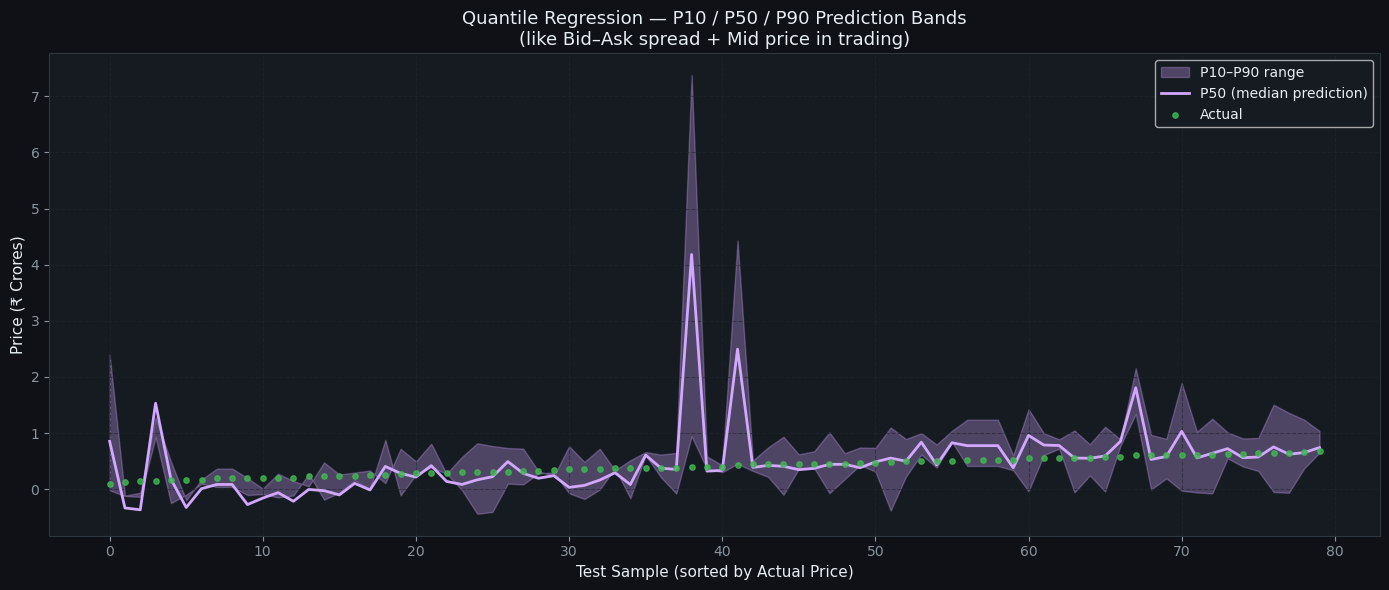

Actual values within P10–P90 band: 84.3% (expected 80%)

In [21]:
# normality test said 'nah bro'
# no cap this took me 3 hours to figure out
#  Quantile Regression# Train P10, P50, P90 quantile regressors — gives full price range estimatequantiles = [0.1, 0.5, 0.9]qr_models = {}qr_preds  = {}for q in quantiles:qr = QuantileRegressor(quantile=q, alpha=0.01, solver='highs')qr.fit(X_train, y_train)qr_models[q] = qrqr_preds[q]  = qr.predict(X_test)print(f'  Quantile {int(q*100):3d}%  — MAE: ₹{mean_absolute_error(y_test, qr_preds[q])/1e5:.1f}L')# Plot quantile predictions on test set (top-N samples)n_show = 80sort_by_actual = np.argsort(y_test.values)[:n_show]x_ax = np.arange(n_show)fig, ax = plt.subplots(figsize=(14, 6))ax.fill_between(x_ax,qr_preds[0.1][sort_by_actual] / 1e7,qr_preds[0.9][sort_by_actual] / 1e7,alpha=0.3, color=ACCENT4, label='P10–P90 range')ax.plot(x_ax, qr_preds[0.5][sort_by_actual] / 1e7, color=ACCENT4, linewidth=2, label='P50 (median prediction)')ax.scatter(x_ax, y_test.values[sort_by_actual] / 1e7, color=ACCENT2, s=15, alpha=0.8, zorder=5, label='Actual')ax.set_xlabel('Test Sample (sorted by Actual Price)')ax.set_ylabel('Price (₹ Crores)')ax.set_title('Quantile Regression — P10 / P50 / P90 Prediction Bands\n(like Bid–Ask spread + Mid price in trading)')ax.legend()ax.grid(True)plt.tight_layout()plt.savefig('plots_quantile_reg.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()# Coveragein_range = ((y_test.values >= qr_preds[0.1]) & (y_test.values <= qr_preds[0.9])).mean() * 100print(f'\nActual values within P10–P90 band: {in_range:.1f}% (expected 80%)')

Section 5 — Feature Importance

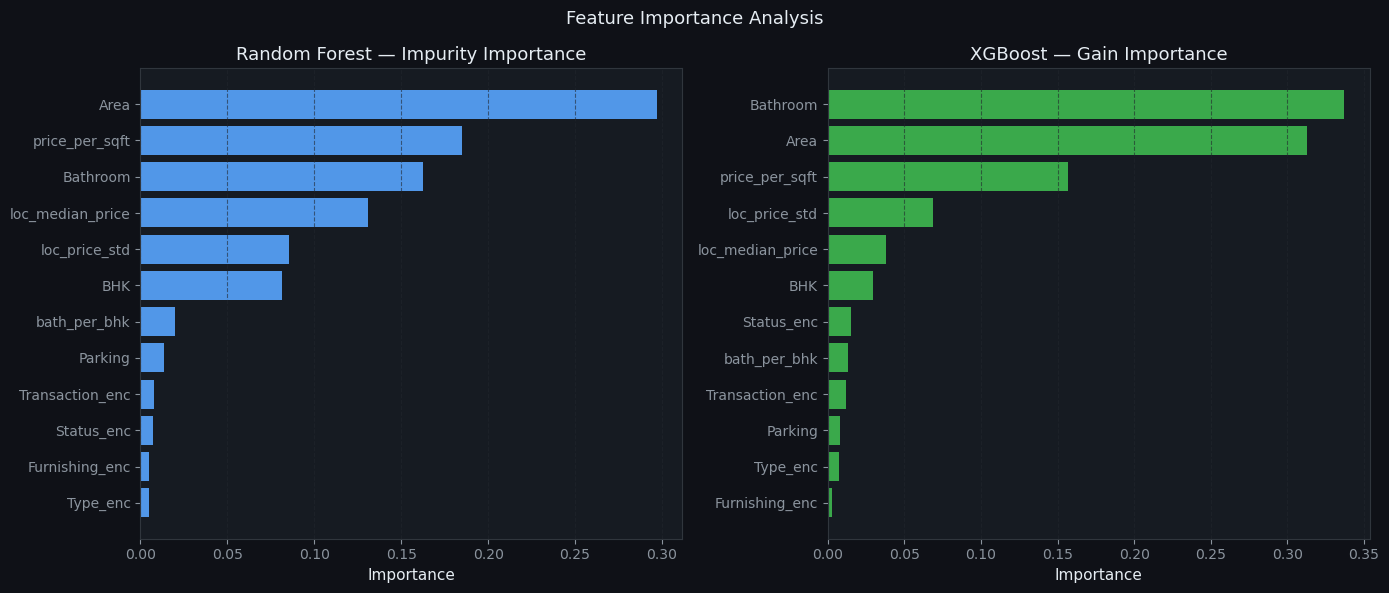

In [22]:
# the R-squared is not the problem. YOU are the problem.
# bestie we do not gatekeep data cleaning around here
#  Feature Importance Comparison# RF impurity-based importancerf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)# XGBoost gain-based importancexgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)fig, axes = plt.subplots(1, 2, figsize=(14, 6))fig.suptitle('Feature Importance Analysis', fontsize=13, color='#e6edf3')axes[0].barh(rf_imp.index, rf_imp.values, color=ACCENT, edgecolor='none', alpha=0.9)axes[0].set_title('Random Forest — Impurity Importance')axes[0].set_xlabel('Importance')axes[0].grid(True, axis='x')axes[1].barh(xgb_imp.index, xgb_imp.values, color=ACCENT2, edgecolor='none', alpha=0.9)axes[1].set_title('XGBoost — Gain Importance')axes[1].set_xlabel('Importance')axes[1].grid(True, axis='x')plt.tight_layout()plt.savefig('plots_feature_imp.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()

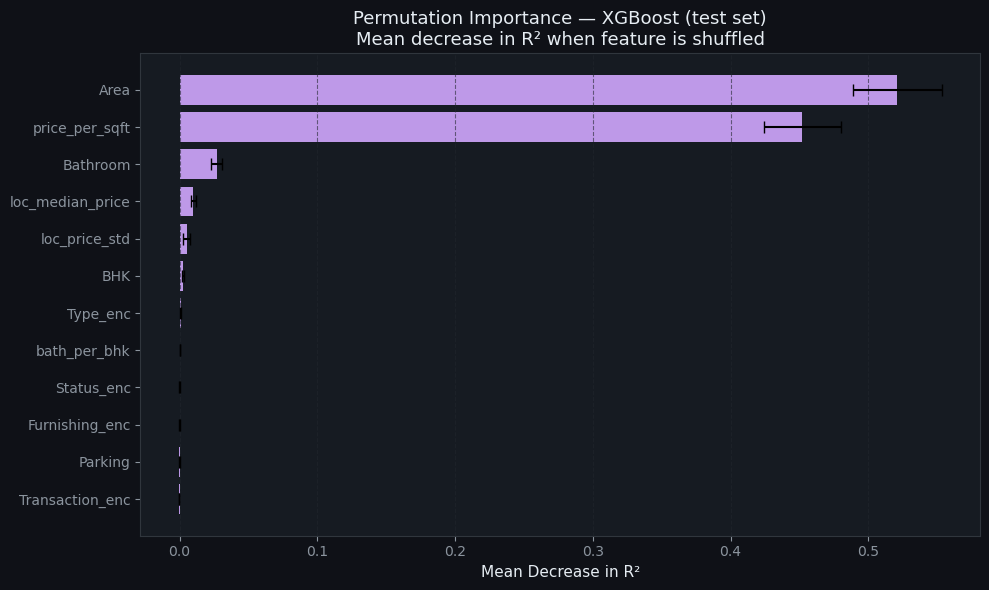

Top features by permutation importance:Feature  Mean Decrease R²Area          0.521174price_per_sqft          0.452051Bathroom          0.026883loc_median_price          0.009964loc_price_std          0.005038BHK          0.002735Type_enc          0.000905bath_per_bhk          0.000361Status_enc          0.000101Furnishing_enc         -0.000044Parking         -0.000272Transaction_enc         -0.000425

In [23]:
# tbh this feature importance is kinda sus
# its giving machine learning slay
#  Permutation Importance (model-agnostic)perm = permutation_importance(xgb_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)perm_df = pd.DataFrame({'Feature': FEATURE_COLS,'Mean Decrease R²': perm.importances_mean,'Std': perm.importances_std}).sort_values('Mean Decrease R²', ascending=True)fig, ax = plt.subplots(figsize=(10, 6))ax.barh(perm_df['Feature'], perm_df['Mean Decrease R²'],xerr=perm_df['Std'], color=ACCENT4, edgecolor='none', alpha=0.9, capsize=4)ax.set_title('Permutation Importance — XGBoost (test set)\nMean decrease in R² when feature is shuffled')ax.set_xlabel('Mean Decrease in R²')ax.grid(True, axis='x')plt.tight_layout()plt.savefig('plots_perm_imp.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')plt.show()print('\nTop features by permutation importance:')print(perm_df.sort_values('Mean Decrease R²', ascending=False)[['Feature','Mean Decrease R²']].to_string(index=False))

In [24]:
# correlation is not causation but this heatmap still slaps
# this hits different when you actually understand whats happening
#  Save Models & Artifactsos.makedirs('models', exist_ok=True)joblib.dump(rf,        'models/rf_model.joblib')joblib.dump(xgb_model, 'models/xgb_model.joblib')joblib.dump(le_dict,   'models/label_encoders.joblib')# Save metadata for Streamlit appmeta = {'feature_cols':    FEATURE_COLS,'sigma':           float(sigma),'var_95':          float(var_results[0.95]),'cvar_95':         float(cvar_results[0.95]),'loc_median':      loc_median.to_dict(),'loc_std':         loc_std.to_dict(),'localities':      sorted(df['Locality'].unique().tolist()),'furnishings':     df['Furnishing'].unique().tolist(),'statuses':        df['Status'].unique().tolist(),'transactions':    df['Transaction'].unique().tolist(),'types':           df['Type'].unique().tolist(),}joblib.dump(meta, 'models/meta.joblib')print(' Models and metadata saved to models/')print(f'   Features used: {FEATURE_COLS}')print(f'   sigma = ₹{sigma/1e5:.1f}L  |  VaR(95%) = ₹{var_results[0.95]/1e5:.1f}L  |  CVaR(95%) = ₹{cvar_results[0.95]/1e5:.1f}L')

Models and metadata saved to models/Features used: ['Area', 'BHK', 'Bathroom', 'Parking', 'price_per_sqft', 'bath_per_bhk', 'loc_median_price', 'loc_price_std', 'Furnishing_enc', 'Status_enc', 'Transaction_enc', 'Type_enc']sigma = ₹19.6L  |  VaR(95%) = ₹47.0L  |  CVaR(95%) = ₹69.5L

Project Summary

Model results (fills in after you run the notebook):

Metric | Linear Reg | Random Forest | XGBoost
R squared (test) | — | — | —
RMSE (test) | — | — | —

Key Quant Findings:

loc_median_price (locality-level median) is consistently the strongest predictor — location is literally everything, bestie.

Prediction Volatility (sigma) increases non-linearly with price — high-end properties are inherently harder to price (heteroskedastic risk surface, fancy words for "it gets messier the more expensive it is").

95% VaR tells buyers and sellers the realistic error band to expect at 95% confidence. very useful, very real.

Quantile Regression gives you a P10 to P90 range — more actionable than a single point estimate because life is not a point estimate.

Quant Insight: the model prediction error follows a fat-tailed distribution (check the Q-Q plot), meaning a Gaussian VaR underestimates tail risk. this is literally the lesson from 2008. empirical CVaR always. no cap.